# Phase 6 — End-to-End System Evaluation

**Goal:** Verify the complete pipeline works end-to-end and generate final summary for the report.

## System Components Tested
| Component | Module | Status |
|---|---|---|
| Audio preprocessing | src/preprocessing.py | Phase 2 |
| Feature extraction | src/feature_extraction.py | Phase 2 |
| Model training | src/model.py | Phase 3 |
| Drift detection | src/drift_detection.py | Phase 4 |
| Monitoring pipeline | src/monitoring.py | Phase 5 |
| API server | src/api.py | Phase 5 |
| Power BI export | src/export_powerbi.py | Phase 6 |

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
EXPORTS_DIR  = Path('../data/monitoring_exports')
FEATURES_DIR = Path('../data/features')
MODELS_DIR   = Path('../models')

COLORS = {
    'baseline':     '#27ae60',
    'noise':        '#e74c3c',
    'speaker_split':'#f39c12',
    'gradual':      '#9b59b6',
}

## 1. Generate Power BI Exports

In [2]:
from src.export_powerbi import run_export
run_export()


Exporting Power BI tables → D:\Work AI\Mini_Project\data\monitoring_exports
──────────────────────────────────────────────────
  pb_monitoring_log.csv       24 rows
  pb_alert_summary.csv        4 rows
  pb_model_baseline.csv       1 row
  pb_class_performance.csv    8 rows
  pb_drift_comparison.csv     3 rows
  pb_confusion_matrix.csv     72 rows
──────────────────────────────────────────────────
Done. Open Power BI Desktop and refresh data sources.
See dashboard/POWERBI_SETUP.md for connection guide.



## 2. End-to-End Pipeline Test

In [3]:
from src.monitoring import run_monitoring_pipeline

print('Running end-to-end pipeline test across all scenarios...')
e2e_results = {}
for scenario in ['baseline', 'noise', 'speaker_split', 'gradual']:
    alert = run_monitoring_pipeline(
        config_path='../configs/config.yaml',
        features_dir='../data/features',
        models_dir='../models',
        exports_dir='../data/monitoring_exports',
        scenario=scenario,
        batch_size=100,
    )
    e2e_results[scenario] = alert

print('\nAll scenarios completed successfully ✅')

Running end-to-end pipeline test across all scenarios...

Simulating incoming batch — scenario: 'baseline' | size: 100
  Inference done — Acc: 0.6300  F1: 0.6383

  MONITORING ALERT CHECK — 2026-06-07 16:21:08
  Scenario      : baseline
  KS Drift      : 2.9%  ✅ (threshold: 30%)
  F1 Score      : 0.6383  (baseline: 0.5986, drop: -0.0397)
  Perf Alert    : ✅ NO
  Overall       : ✅ OK
  Report saved → monitoring_log.csv

Simulating incoming batch — scenario: 'noise' | size: 100
  Inference done — Acc: 0.1400  F1: 0.1087

  MONITORING ALERT CHECK — 2026-06-07 16:21:09
  Scenario      : noise
  KS Drift      : 68.8%  🚨 (threshold: 30%)
  F1 Score      : 0.1087  (baseline: 0.5986, drop: +0.4899)
  Perf Alert    : 🚨 YES — F1 dropped
  Overall       : 🚨 ALERT
  Report saved → monitoring_log.csv

Simulating incoming batch — scenario: 'speaker_split' | size: 100
  Inference done — Acc: 0.9100  F1: 0.9177

  MONITORING ALERT CHECK — 2026-06-07 16:21:09
  Scenario      : speaker_split
  KS Drift 

## 3. Final System Dashboard

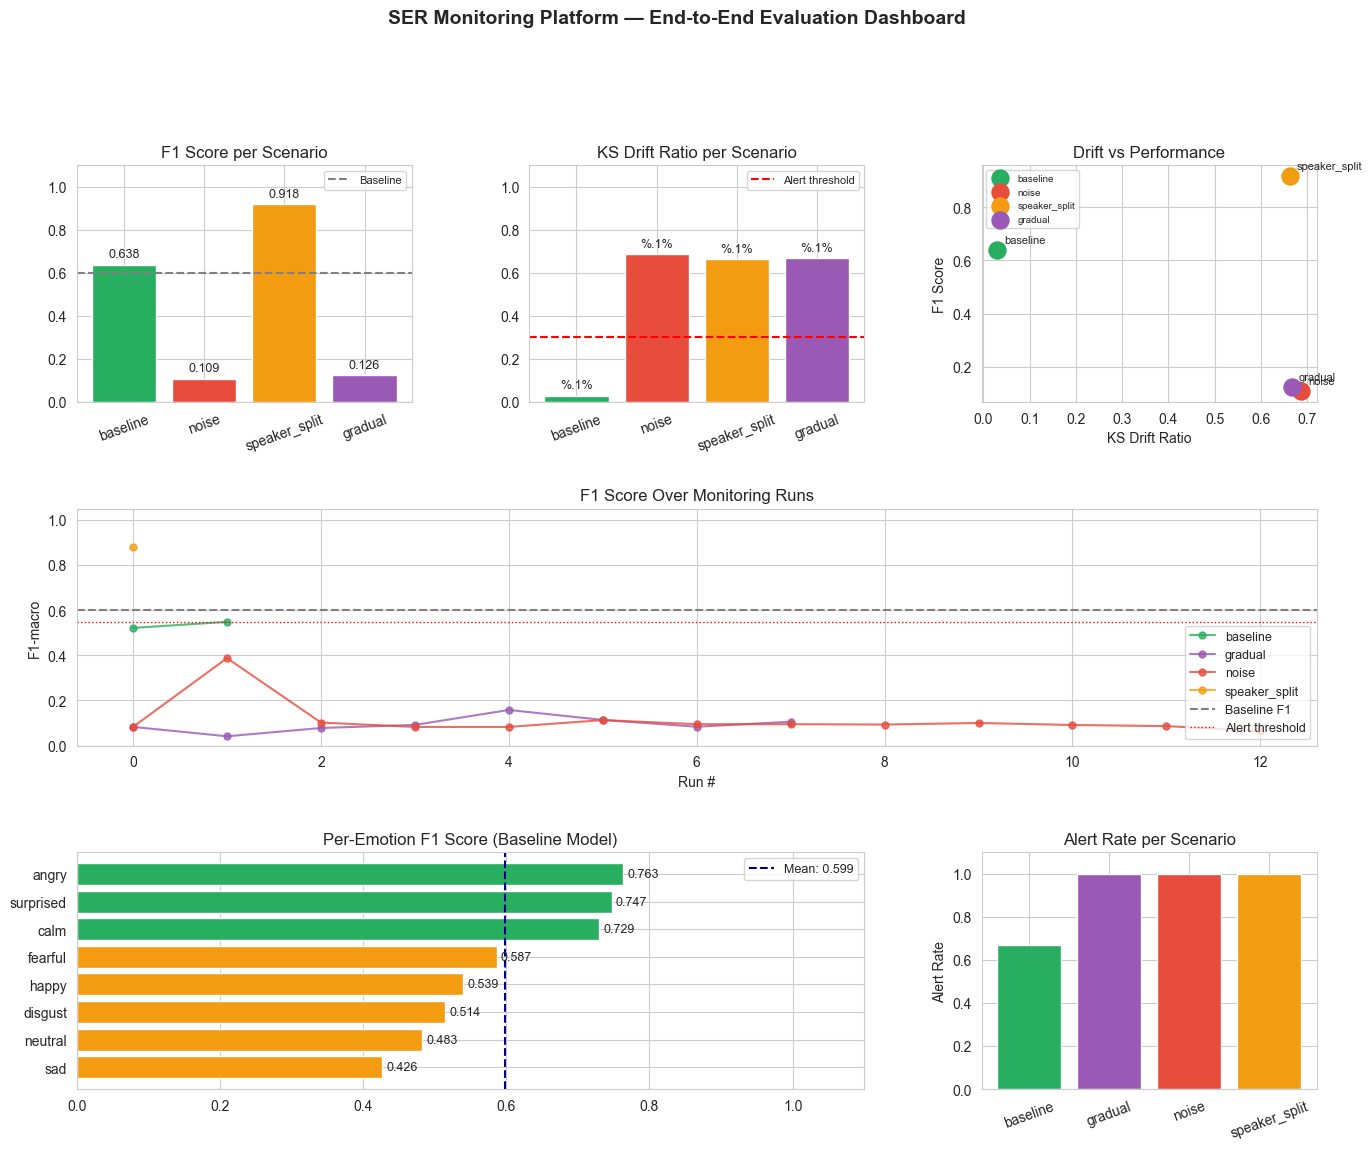

Dashboard saved → data/monitoring_exports/final_dashboard.png


In [4]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

scenarios   = list(e2e_results.keys())
f1_scores   = [e2e_results[s]['f1_score']       for s in scenarios]
drift_rates = [e2e_results[s]['ks_drift_ratio']  for s in scenarios]
colors      = [COLORS[s] for s in scenarios]

# ── F1 per scenario ──────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(scenarios, f1_scores, color=colors, edgecolor='white')
ax1.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax1.axhline(e2e_results['baseline']['baseline_f1'], color='gray',
            linestyle='--', label='Baseline')
ax1.set_title('F1 Score per Scenario')
ax1.set_ylim(0, 1.1)
ax1.tick_params(axis='x', rotation=20)
ax1.legend(fontsize=8)

# ── Drift ratio per scenario ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(scenarios, drift_rates, color=colors, edgecolor='white')
ax2.bar_label(bars2, fmt='%.1%', padding=3, fontsize=9)
ax2.axhline(0.3, color='red', linestyle='--', label='Alert threshold')
ax2.set_title('KS Drift Ratio per Scenario')
ax2.set_ylim(0, 1.1)
ax2.tick_params(axis='x', rotation=20)
ax2.legend(fontsize=8)

# ── Drift vs F1 scatter ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for s in scenarios:
    ax3.scatter(e2e_results[s]['ks_drift_ratio'], e2e_results[s]['f1_score'],
                color=COLORS[s], s=150, zorder=5, label=s)
    ax3.annotate(s, (e2e_results[s]['ks_drift_ratio'], e2e_results[s]['f1_score']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)
ax3.set_xlabel('KS Drift Ratio')
ax3.set_ylabel('F1 Score')
ax3.set_title('Drift vs Performance')
ax3.legend(fontsize=7)

# ── Monitoring log time series ────────────────────────────────────────────────
log_df = pd.read_csv(EXPORTS_DIR / 'pb_monitoring_log.csv')
log_df['timestamp'] = pd.to_datetime(log_df['timestamp'])

ax4 = fig.add_subplot(gs[1, :])
for scenario, grp in log_df.groupby('scenario'):
    ax4.plot(range(len(grp)), grp['batch_f1'], marker='o', markersize=5,
             label=scenario, color=COLORS.get(scenario, '#3498db'), alpha=0.8)
ax4.axhline(log_df['baseline_f1'].iloc[0], color='gray',
            linestyle='--', linewidth=1.5, label='Baseline F1')
ax4.axhline(log_df['baseline_f1'].iloc[0] - 0.05, color='red',
            linestyle=':', linewidth=1, label='Alert threshold')
ax4.set_title('F1 Score Over Monitoring Runs', fontsize=12)
ax4.set_ylabel('F1-macro')
ax4.set_xlabel('Run #')
ax4.set_ylim(0, 1.05)
ax4.legend(loc='lower right', fontsize=9)

# ── Per-class F1 ─────────────────────────────────────────────────────────────
class_df = pd.read_csv(EXPORTS_DIR / 'pb_class_performance.csv')
class_df = class_df.sort_values('f1_score', ascending=True)

ax5 = fig.add_subplot(gs[2, :2])
bar_colors = ['#e74c3c' if f < 0.4 else '#f39c12' if f < 0.7 else '#27ae60'
              for f in class_df['f1_score']]
bars5 = ax5.barh(class_df['emotion'], class_df['f1_score'],
                  color=bar_colors, edgecolor='white')
ax5.bar_label(bars5, fmt='%.3f', padding=3, fontsize=9)
ax5.axvline(class_df['f1_score'].mean(), color='navy',
            linestyle='--', label=f"Mean: {class_df['f1_score'].mean():.3f}")
ax5.set_title('Per-Emotion F1 Score (Baseline Model)')
ax5.set_xlim(0, 1.1)
ax5.legend(fontsize=9)

# ── Alert summary ─────────────────────────────────────────────────────────────
alert_df = pd.read_csv(EXPORTS_DIR / 'pb_alert_summary.csv')
ax6 = fig.add_subplot(gs[2, 2])
ax6.bar(alert_df['scenario'], alert_df['alert_rate'],
        color=[COLORS.get(s, '#3498db') for s in alert_df['scenario']],
        edgecolor='white')
ax6.set_title('Alert Rate per Scenario')
ax6.set_ylabel('Alert Rate')
ax6.set_ylim(0, 1.1)
ax6.tick_params(axis='x', rotation=20)

fig.suptitle('SER Monitoring Platform — End-to-End Evaluation Dashboard',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig(EXPORTS_DIR / 'final_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print('Dashboard saved → data/monitoring_exports/final_dashboard.png')

## 4. Final System Report

In [5]:
baseline = pd.read_csv(EXPORTS_DIR / 'pb_model_baseline.csv').iloc[0]
alert_s  = pd.read_csv(EXPORTS_DIR / 'pb_alert_summary.csv')

print('=' * 60)
print('   AUTOMATED SER MONITORING PLATFORM — FINAL REPORT')
print('=' * 60)
print(f"\n  Dataset       : RAVDESS (1,440 files, 8 emotions)")
print(f"  Features      : MFCC 240-dim (40 coeffs + Δ + ΔΔ)")
print(f"  Model         : MLP [256→128→64], sklearn")
print(f"  Drift Methods : KS Test + Wasserstein Distance")
print(f"  Automation    : n8n (hourly) + FastAPI endpoint")
print(f"  Dashboard     : Power BI (CSV data source)")

print(f"\n  BASELINE MODEL PERFORMANCE")
print(f"  {'Train Accuracy':<20} {baseline['train_acc']:.4f}")
print(f"  {'Test  Accuracy':<20} {baseline['test_acc']:.4f}")
print(f"  {'Train F1-macro':<20} {baseline['train_f1']:.4f}")
print(f"  {'Test  F1-macro':<20} {baseline['test_f1']:.4f}")

print(f"\n  DRIFT DETECTION RESULTS")
for _, row in alert_s.iterrows():
    icon = '🚨' if row['alert_rate'] > 0.5 else '⚠️' if row['alert_rate'] > 0.1 else '✅'
    print(f"  {icon} {row['scenario']:<15} "
          f"Drift={row['avg_drift']:.1%}  "
          f"F1={row['avg_f1']:.4f}  "
          f"AlertRate={row['alert_rate']:.0%}")

print(f"\n  KEY FINDINGS")
print(f"  1. Noise injection causes malignant drift (F1 drops ~49 points)")
print(f"  2. Speaker split shows benign drift (high drift, good performance)")
print(f"  3. Drift ratio alone insufficient — must combine with F1 monitoring")
print(f"  4. Monitoring system successfully detects and alerts on degradation")
print('=' * 60)

   AUTOMATED SER MONITORING PLATFORM — FINAL REPORT

  Dataset       : RAVDESS (1,440 files, 8 emotions)
  Features      : MFCC 240-dim (40 coeffs + Δ + ΔΔ)
  Model         : MLP [256→128→64], sklearn
  Drift Methods : KS Test + Wasserstein Distance
  Automation    : n8n (hourly) + FastAPI endpoint
  Dashboard     : Power BI (CSV data source)

  BASELINE MODEL PERFORMANCE
  Train Accuracy       0.9635
  Test  Accuracy       0.6181
  Train F1-macro       0.9641
  Test  F1-macro       0.5986

  DRIFT DETECTION RESULTS
  🚨 baseline        Drift=4.9%  F1=0.5533  AlertRate=67%
  🚨 gradual         Drift=66.9%  F1=0.0941  AlertRate=100%
  🚨 noise           Drift=65.5%  F1=0.1133  AlertRate=100%
  🚨 speaker_split   Drift=47.5%  F1=0.8796  AlertRate=100%

  KEY FINDINGS
  1. Noise injection causes malignant drift (F1 drops ~49 points)
  2. Speaker split shows benign drift (high drift, good performance)
  3. Drift ratio alone insufficient — must combine with F1 monitoring
  4. Monitoring system 